# Ingolstadt 21 (`sumo1x21`) — full experiment report

Arterial corridor, **21 TLS**, seed **42**. Four SLURM groups from `extras/submit_ingolstadt_1x21_chained.sh`.

| § | Block | Prefix | Notes |
|---|---|---|---|
| 1 | Baseline ES | `homo_1x21_es` | Adaptive early-stop |
| 2 | Baseline fixed-200 | `homo_1x21` / `homo_1x21_e200` | RL = 200 episodes |
| 3 | Axes | `axis_{*}_1x21_es` | One realism axis × 5 methods |
| 4–5 | OD-hub L1 / L2 | `odh_l{1,2}_1x21_es` | Held-out early-stop |
| 6 | vs `sumo4x4` | — | Ranking / realism / OD commentary |

**Primary ATT:** RL = best TEST (DTL); FT/MP = Final (BRF); OD-hub = HELDOUT_MEAN when present.

**Learning curves** follow `realism_benchmark_4x4.ipynb`: one panel per RL method, **train (dashed) + test (solid)**.

**Last local refresh:** 2026-08-09 — all blocks OK including `homo_1x21_es` (restored from feat/early-stop-episodes).

Missing BRF/DTL → **`needs update`** (often the run dir synced without `logger/`).


In [1]:
import re
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def _find_repo() -> Path:
    """Resolve repo root whether cwd is result_analysis/ or repo root."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'data' / 'output_data' / 'tsc').is_dir() and (cand / 'run.py').is_file():
            return cand
    # fallback: notebook lives in result_analysis/
    return Path('..').resolve()

REPO = _find_repo()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'col5', 'reward', 'queue', 'delay', 'throughput']
METHODS = ['MaxPressure', 'FixedTime', 'DQN', 'PressLight', 'CoLight']
RL = ['DQN', 'PressLight', 'CoLight']
METHOD_SLUG = {
    'FixedTime': 'fixedtime', 'MaxPressure': 'maxpressure',
    'DQN': 'dqn', 'PressLight': 'presslight', 'CoLight': 'colight',
}
COLORS = {
    'DQN': '#4C72B0', 'PressLight': '#55A868', 'CoLight': '#C44E52',
    'MaxPressure': '#CCB974', 'FixedTime': '#64B5CD',
}
AXES = ['hetero', 'slow_start', 'crossing_proxy', 'obs', 'noise']
AXIS_LABEL = {
    'hetero': 'Hetero fleet',
    'slow_start': 'Slow-start',
    'crossing_proxy': 'Crossing proxy',
    'obs': 'Partial obs (p=0.1)',
    'noise': 'Count noise',
}
NETWORK = 'sumo1x21'
MISSING = 'needs update'


def load_dtl(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep='\t', header=None, names=COLS)


def latest(path, pattern: str):
    if path is None or not Path(path).exists():
        return None
    files = sorted(Path(path).glob(pattern))
    return files[-1] if files else None


def final_travel_time(brf: Path):
    hits = re.findall(r'Final Travel Time is ([0-9.]+)', Path(brf).read_text(errors='ignore'))
    return float(hits[-1]) if hits else None


def parse_early_stop(brf: Path):
    txt = Path(brf).read_text(errors='ignore')
    m = re.search(
        r'early_stop at episode (\d+)/(\d+) \(best ATT=([0-9.]+) at episode (\d+)',
        txt,
    )
    if not m:
        return None
    return {
        'stop_episode': int(m.group(1)),
        'max_episodes': int(m.group(2)),
        'best_att_logged': float(m.group(3)),
        'best_episode': int(m.group(4)),
    }


def heldout_mean(brf: Path):
    txt = Path(brf).read_text(errors='ignore')
    m = re.findall(r'HELDOUT_MEAN episode:\d+/\d+, travel time:([0-9.]+)', txt)
    if m:
        return float(m[-1])
    hits = re.findall(r'HELDOUT episode:.*?travel time:([0-9.]+)', txt)
    if hits:
        return float(statistics.mean(float(x) for x in hits))
    return None


def logdir(agent_slug: str, network: str, prefix: str) -> Path:
    return OUT / f'sumo_{agent_slug}' / network / prefix / 'logger'


def summarize_run(agent_slug: str, prefix: str, method: str,
                  network: str = NETWORK, prefer_heldout: bool = False):
    path = logdir(agent_slug, network, prefix)
    dtl = latest(path, '*DTL.log')
    brf = latest(path, '*BRF.log')
    row = {
        'method': method, 'agent': agent_slug, 'prefix': prefix, 'network': network,
        'status': MISSING, 'episodes_trained': None, 'early_stopped': False,
        'best_TEST_ATT': None, 'best_TEST_episode': None, 'last_TEST_ATT': None,
        'final_ATT': None, 'heldout_ATT': None, 'primary_ATT': None,
        'log': None, 'note': '', 'dtl_path': None, 'brf_path': None,
    }
    parent = path.parent
    if brf is None and dtl is None:
        if parent.exists() and not path.exists():
            row['note'] = 'run dir present but logger/ missing — re-sync loggers'
        elif path.exists():
            row['note'] = 'logger/ empty — re-sync BRF/DTL from gpujobs'
        else:
            row['note'] = 'not found locally'
        return row

    row['status'] = 'ok'
    row['brf_path'] = brf
    row['dtl_path'] = dtl
    if brf:
        row['final_ATT'] = final_travel_time(brf)
        row['heldout_ATT'] = heldout_mean(brf)
        stop = parse_early_stop(brf)
        if stop:
            row['early_stopped'] = True
            row['episodes_trained'] = stop['stop_episode'] + 1
        row['log'] = brf.name
        if 'smoke' in prefix:
            row['status'] = 'partial'
            row['note'] = 'smoke only — needs full job sync'

    if dtl:
        df = load_dtl(dtl)
        test = df[df.split == 'TEST']
        train = df[df.split == 'TRAIN']
        row['log'] = dtl.name
        if not test.empty:
            best = test.loc[test.travel_time.idxmin()]
            last = test.iloc[-1]
            row['best_TEST_ATT'] = float(best.travel_time)
            row['best_TEST_episode'] = int(best.episode)
            row['last_TEST_ATT'] = float(last.travel_time)
            row['episodes_trained'] = int(test.episode.max()) + 1
        elif not train.empty:
            row['episodes_trained'] = int(train.episode.max()) + 1

    if row['episodes_trained'] is None and row['final_ATT'] is not None:
        row['episodes_trained'] = 1

    if prefer_heldout and row['heldout_ATT'] is not None:
        row['primary_ATT'] = row['heldout_ATT']
    elif method in RL and row['best_TEST_ATT'] is not None:
        row['primary_ATT'] = row['best_TEST_ATT']
    else:
        row['primary_ATT'] = row['final_ATT'] if row['final_ATT'] is not None else row['heldout_ATT']

    if row['primary_ATT'] is None and row['status'] == 'ok':
        row['status'] = 'partial'
        row['note'] = row['note'] or 'log present but no ATT parsed'
    return row


def try_candidates(method: str, candidates: list, prefer_heldout: bool = False):
    last = None
    for item in candidates:
        agent, pref = item[0], item[1]
        net = item[2] if len(item) > 2 else NETWORK
        row = summarize_run(agent, pref, method, network=net, prefer_heldout=prefer_heldout)
        last = row
        if row['status'] != MISSING:
            if item != candidates[0]:
                row['note'] = (row['note'] + '; ' if row['note'] else '') + f'fallback {agent}/{pref}'
            return row
    return last


def show_table(df: pd.DataFrame, cols=None):
    cols = cols or ['status', 'episodes_trained', 'early_stopped', 'best_TEST_ATT',
                    'final_ATT', 'heldout_ATT', 'primary_ATT', 'log', 'note']
    cols = [c for c in cols if c in df.columns]
    display(df[cols])


def bar_primary(df: pd.DataFrame, title: str):
    ok = df[df['primary_ATT'].notna()].copy()
    if ok.empty:
        print(f'(no ATT to plot for {title})')
        return
    order = [m for m in METHODS if m in ok.index]
    vals = [ok.loc[m, 'primary_ATT'] for m in order]
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.barh(order[::-1], vals[::-1], color=[COLORS[m] for m in order[::-1]])
    ax.set_xlabel('primary ATT (s)')
    ax.set_title(title)
    ax.grid(True, axis='x', alpha=0.3)
    for i, v in enumerate(vals[::-1]):
        ax.text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_rl_curves(df: pd.DataFrame, title: str):
    """Realism-notebook style: 1×3 panels, train dashed + eval solid.

    Eval split is auto-detected:
      - standard runs: TEST
      - OD-hub runs: HELDOUT_MEAN (falls back to mean of HELDOUT rows per episode)
    Individual HELDOUT file scores are shown as light markers when present.
    """
    rl_data = {}
    for name in RL:
        if name not in df.index:
            continue
        dtl = df.loc[name, 'dtl_path']
        if dtl is None or not Path(dtl).exists():
            continue
        full = load_dtl(Path(dtl))
        tr = full[full.split == 'TRAIN'].reset_index(drop=True)
        te = full[full.split == 'TEST'].reset_index(drop=True)
        hm = full[full.split == 'HELDOUT_MEAN'].reset_index(drop=True)
        ho = full[full.split == 'HELDOUT'].reset_index(drop=True)
        if te.empty and not hm.empty:
            te = hm
            eval_label = 'heldout'
        elif te.empty and not ho.empty:
            te = (ho.groupby('episode', as_index=False)['travel_time'].mean())
            eval_label = 'heldout'
        else:
            eval_label = 'test'
        if tr.empty and te.empty:
            continue
        rl_data[name] = {
            'train': tr, 'test': te, 'heldout_raw': ho,
            'eval_label': eval_label,
        }

    if not rl_data:
        print(f'(no RL DTL curves for {title})')
        return

    names = [n for n in RL if n in rl_data]
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4.2), sharey=True)
    if len(names) == 1:
        axes = [axes]
    for ax, name in zip(axes, names):
        tr = rl_data[name]['train']
        te = rl_data[name]['test']
        ho = rl_data[name]['heldout_raw']
        eval_label = rl_data[name]['eval_label']
        # OD-hub early-stop logs a final HELDOUT at max_episodes (e.g. 500) after
        # stopping — that creates a fake long diagonal. Keep in-training evals only;
        # show the final heldout as a marker at the last train episode.
        final_heldout = None
        if not tr.empty and eval_label == 'heldout':
            tmax = int(tr.episode.max())
            gap = 5
            te_post = te[te.episode > tmax + gap]
            te = te[te.episode <= tmax + gap]
            ho = ho[ho.episode <= tmax + gap]
            if not te_post.empty:
                final_heldout = float(te_post.travel_time.iloc[-1])
        if not tr.empty:
            ax.plot(tr.episode, tr.travel_time, color='#4C72B0', linestyle='--',
                    alpha=0.85, label='train')
        if eval_label == 'heldout' and not ho.empty:
            ax.scatter(ho.episode, ho.travel_time, color='#C44E52', s=18,
                       alpha=0.35, zorder=2, label='heldout files')
        if not te.empty:
            ax.plot(te.episode, te.travel_time, color='#C44E52',
                    label=eval_label, zorder=3)
        if final_heldout is not None and not tr.empty:
            ax.scatter([int(tr.episode.max())], [final_heldout], color='#C44E52',
                       marker='*', s=120, zorder=4, label='final heldout')
        ax.set_title(name)
        ax.set_xlabel('episode')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('ATT (s)')
    # dedupe legend labels across panels
    handles, labels = axes[-1].get_legend_handles_labels()
    by = dict(zip(labels, handles))
    axes[-1].legend(by.values(), by.keys(), frameon=False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def sync_hint():
    print('Re-sync ONLY logger trees from gpujobs (Mac):')
    print("  rsync -avz --progress \\")
    print("    --include='*/' --include='**/sumo1x21/**/logger/**' --exclude='*' \\")
    print("    mmirzata@172.20.48.59:~/LibSignalFork/data/output_data/tsc/ \\")
    print("    data/output_data/tsc/")
    print('On gpujobs, verify logs exist first, e.g.:')
    print('  ls data/output_data/tsc/sumo_dqn_hetero/sumo1x21/axis_hetero_1x21_es/logger/')
    print('  ls data/output_data/tsc/sumo_dqn_odh_l1_1x21/sumo1x21/odh_l1_1x21_es/logger/')


print('REPO', REPO)


REPO /Users/ziyodjanmirzataev/Desktop/LibSignalFork


### Local sync health check

If this prints many `DIR_NO_LOG`, you still need to pull `logger/` from gpujobs (model/dataset alone is not enough).


In [2]:
rows = []
checks = []
for m in METHODS:
    checks.append((METHOD_SLUG[m], 'homo_1x21_es', 'baseline ES'))
    checks.append((METHOD_SLUG[m], 'homo_1x21', 'baseline e200-fallback'))
for ax in AXES:
    for m in METHODS:
        checks.append((f'{METHOD_SLUG[m]}_{ax}', f'axis_{ax}_1x21_es', f'axis:{ax}'))
for lvl in ['l1', 'l2']:
    for m in METHODS:
        checks.append((f'{METHOD_SLUG[m]}_odh_{lvl}_1x21', f'odh_{lvl}_1x21_es', f'odh {lvl}'))

for agent, pref, block in checks:
    p = logdir(agent, NETWORK, pref)
    parent = p.parent
    brf = latest(p, '*BRF.log')
    if brf:
        st = 'OK'
    elif parent.exists() and (not p.exists() or not any(p.glob('*.log'))):
        st = 'DIR_NO_LOG'
    else:
        st = 'NO_DIR'
    rows.append({'block': block, 'agent': agent, 'prefix': pref, 'status': st})

health = pd.DataFrame(rows)
display(health.groupby(['block', 'status']).size().unstack(fill_value=0))
bad = health[health.status != 'OK']
print(f"\nIncomplete: {len(bad)} / {len(health)}")
if not bad.empty:
    display(bad)
    sync_hint()
else:
    print('All expected logger trees present.')


status                  OK
block                     
axis:crossing_proxy      5
axis:hetero              5
axis:noise               5
axis:obs                 5
axis:slow_start          5
baseline ES              5
baseline e200-fallback   5
odh l1                   5
odh l2                   5



Incomplete: 0 / 45
All expected logger trees present.


---
## 1 · Baseline early-stop (`homo_1x21_es`)


            status  episodes_trained  early_stopped  best_TEST_ATT  final_ATT heldout_ATT  primary_ATT                          log note
method                                                                                                                                  
MaxPressure     ok                 1          False            NaN   209.0979        None     209.0979  2026_08_06-17_03_15_BRF.log     
FixedTime       ok                 1          False            NaN   248.9316        None     248.9316  2026_08_06-17_02_59_BRF.log     
DQN             ok                57           True          236.5   336.2830        None     236.5000  2026_08_06-17_03_28_DTL.log     
PressLight      ok                67           True          203.2   203.1645        None     203.2000  2026_08_06-17_37_29_DTL.log     
CoLight         ok                47           True          272.5   334.5287        None     272.5000  2026_08_06-18_18_28_DTL.log     


cell_1:199: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


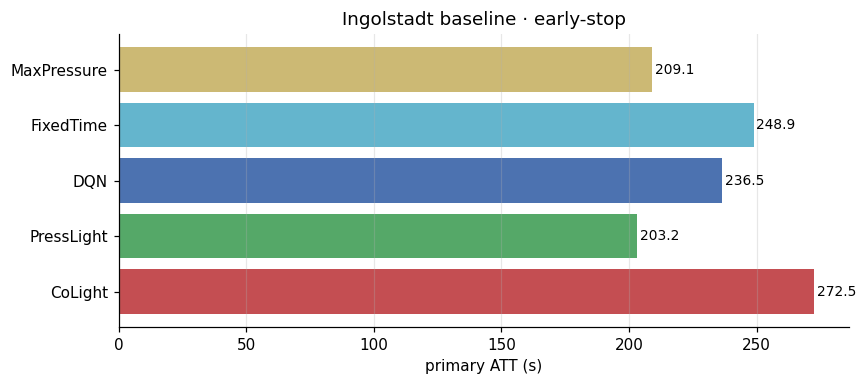

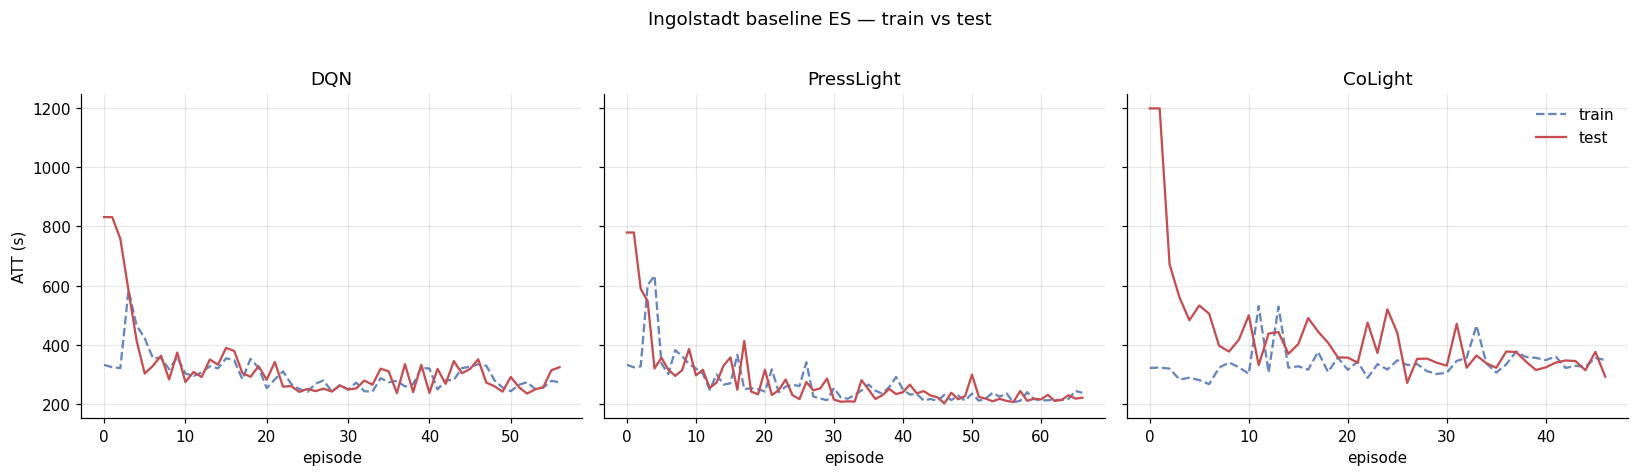

In [3]:
df_es = pd.DataFrame([
    summarize_run(METHOD_SLUG[m], 'homo_1x21_es', m) for m in METHODS
]).set_index('method')
show_table(df_es)
bar_primary(df_es, 'Ingolstadt baseline · early-stop')
plot_rl_curves(df_es, 'Ingolstadt baseline ES — train vs test')


---
## 2 · Baseline fixed 200 episodes

Prefers `homo_1x21_e200`; falls back to local `homo_1x21`.


            status        agent     prefix  episodes_trained  early_stopped  best_TEST_ATT  final_ATT  primary_ATT                          log                            note
method                                                                                                                                                                         
MaxPressure     ok  maxpressure  homo_1x21                 1          False            NaN   217.8406     217.8406  2026_07_28-01_15_03_BRF.log  fallback maxpressure/homo_1x21
FixedTime       ok    fixedtime  homo_1x21                 1          False            NaN   241.7473     241.7473  2026_07_28-01_15_03_BRF.log    fallback fixedtime/homo_1x21
DQN             ok          dqn  homo_1x21               200          False          224.4   296.7729     224.4000  2026_07_28-01_15_03_DTL.log          fallback dqn/homo_1x21
PressLight      ok   presslight  homo_1x21               200          False          213.0   218.8386     213.0000  2026

cell_1:199: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


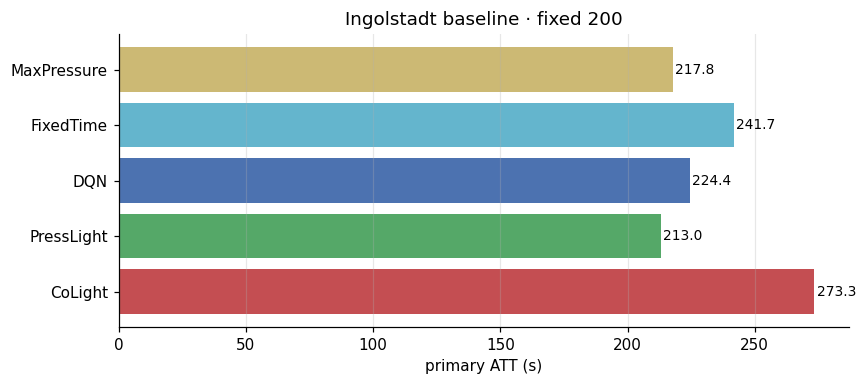

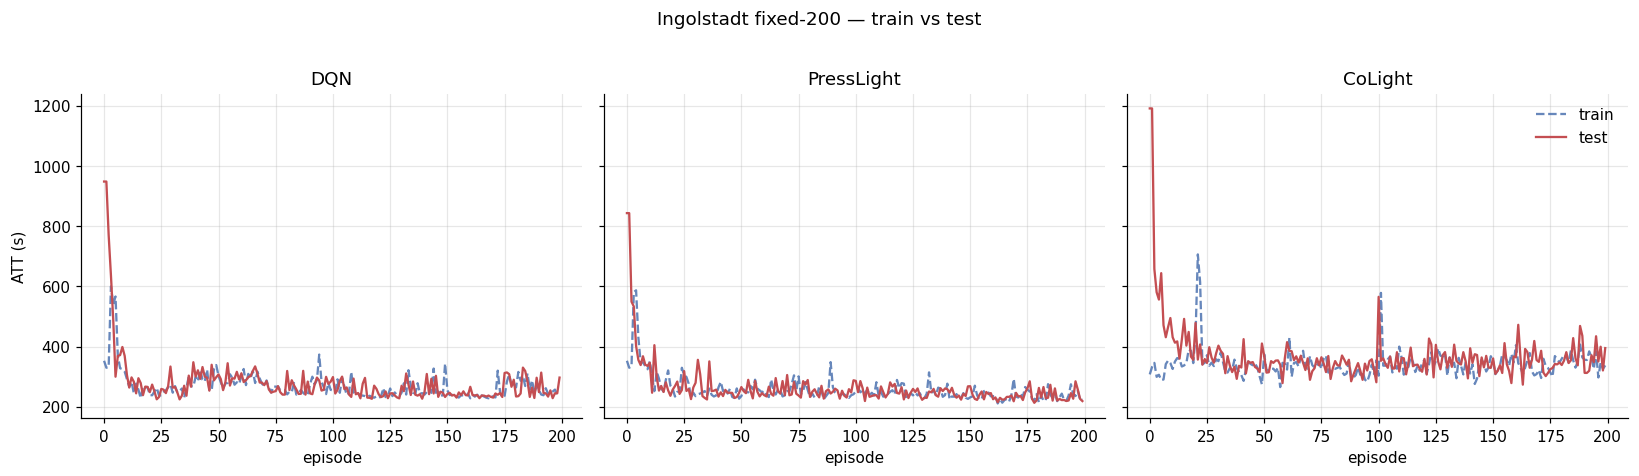

In [4]:
rows_e200 = []
for m in METHODS:
    slug = METHOD_SLUG[m]
    if m in RL:
        cands = [
            (f'{slug}_e200', 'homo_1x21_e200'),
            (slug, 'homo_1x21_e200'),
            (slug, 'homo_1x21'),
        ]
    else:
        cands = [(slug, 'homo_1x21_e200'), (slug, 'homo_1x21')]
    rows_e200.append(try_candidates(m, cands))

df_e200 = pd.DataFrame(rows_e200).set_index('method')
show_table(df_e200, ['status', 'agent', 'prefix', 'episodes_trained', 'early_stopped',
                     'best_TEST_ATT', 'final_ATT', 'primary_ATT', 'log', 'note'])
bar_primary(df_e200, 'Ingolstadt baseline · fixed 200')
plot_rl_curves(df_e200, 'Ingolstadt fixed-200 — train vs test')


### Early-stop vs fixed-200


             ES_ATT  ES_eps  E200_ATT  E200_eps  Δ ATT (e200−es)
method                                                          
MaxPressure  209.10       1    217.84         1             8.74
FixedTime    248.93       1    241.75         1            -7.18
DQN          236.50      57    224.40       200           -12.10
PressLight   203.20      67    213.00       200             9.80
CoLight      272.50      47    273.30       200             0.80


cell_9:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


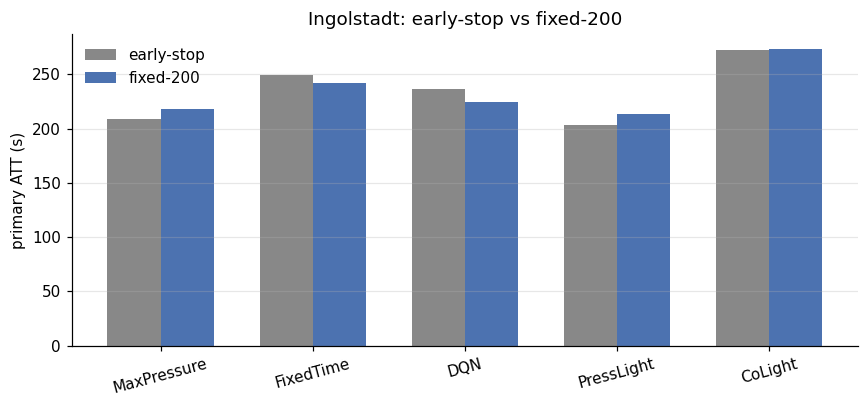

In [5]:
cmp = pd.DataFrame({
    'ES_ATT': df_es['primary_ATT'],
    'ES_eps': df_es['episodes_trained'],
    'E200_ATT': df_e200['primary_ATT'],
    'E200_eps': df_e200['episodes_trained'],
})
cmp['Δ ATT (e200−es)'] = cmp['E200_ATT'] - cmp['ES_ATT']
display(cmp.round(2))

fig, ax = plt.subplots(figsize=(8, 3.8))
x = range(len(METHODS))
w = 0.35
es_vals = [cmp.loc[m, 'ES_ATT'] if pd.notna(cmp.loc[m, 'ES_ATT']) else 0 for m in METHODS]
e2_vals = [cmp.loc[m, 'E200_ATT'] if pd.notna(cmp.loc[m, 'E200_ATT']) else 0 for m in METHODS]
ax.bar([i - w/2 for i in x], es_vals, w, label='early-stop', color='#888888')
ax.bar([i + w/2 for i in x], e2_vals, w, label='fixed-200', color='#4C72B0')
ax.set_xticks(list(x))
ax.set_xticklabels(METHODS, rotation=15)
ax.set_ylabel('primary ATT (s)')
ax.set_title('Ingolstadt: early-stop vs fixed-200')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3 · Single-axis ablations

One realism axis on at a time. Positive Δ vs fixed-200 baseline = worse ATT.


In [6]:
axis_rows = []
for axis in AXES:
    for m in METHODS:
        slug = f"{METHOD_SLUG[m]}_{axis}"
        row = try_candidates(m, [
            (slug, f'axis_{axis}_1x21_es'),
            (slug, f'axis_{axis}_1x21_e200'),
        ])
        row['axis'] = axis
        if row['status'] == MISSING:
            row['note'] = row['note'] or 'needs update — sync logger/ from gpujobs'
        axis_rows.append(row)

df_axes = pd.DataFrame(axis_rows)
pivot_att = df_axes.pivot(index='method', columns='axis', values='primary_ATT').reindex(index=METHODS, columns=AXES)
pivot_status = df_axes.pivot(index='method', columns='axis', values='status').reindex(index=METHODS, columns=AXES)

print('Primary ATT')
display(pivot_att.round(1).rename(columns=AXIS_LABEL))
print('Status')
display(pivot_status.rename(columns=AXIS_LABEL))

n_ok = int((df_axes.status == 'ok').sum())
print(f'Coverage: {n_ok}/25 ok locally')
miss = df_axes[df_axes.status != 'ok'][['axis', 'method', 'status', 'note']]
if not miss.empty:
    display(miss)


axis         Hetero fleet  Slow-start  Crossing proxy  Partial obs (p=0.1)  Count noise
method                                                                                 
MaxPressure         336.2       308.5           227.7                587.0        243.9
FixedTime           342.3       434.6           285.1                270.3        270.3
DQN                 353.8       317.9           316.2                533.7        348.9
PressLight          318.6       301.6           249.3                556.9        297.9
CoLight             463.3       502.0           401.9                530.2        389.1


axis        Hetero fleet Slow-start Crossing proxy Partial obs (p=0.1) Count noise
method                                                                            
MaxPressure           ok         ok             ok                  ok          ok
FixedTime             ok         ok             ok                  ok          ok
DQN                   ok         ok             ok                  ok          ok
PressLight            ok         ok             ok                  ok          ok
CoLight               ok         ok             ok                  ok          ok


Primary ATT
Status
Coverage: 25/25 ok locally


axis         Hetero fleet  Slow-start  Crossing proxy  Partial obs (p=0.1)  Count noise
method                                                                                 
MaxPressure         118.4        90.7             9.9                369.2         26.0
FixedTime           100.5       192.9            43.4                 28.5         28.5
DQN                 129.4        93.5            91.8                309.3        124.5
PressLight          105.6        88.6            36.3                343.9         84.9
CoLight             190.0       228.7           128.6                256.9        115.8


Δ ATT vs fixed-200 baseline (positive = worse)


cell_12:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


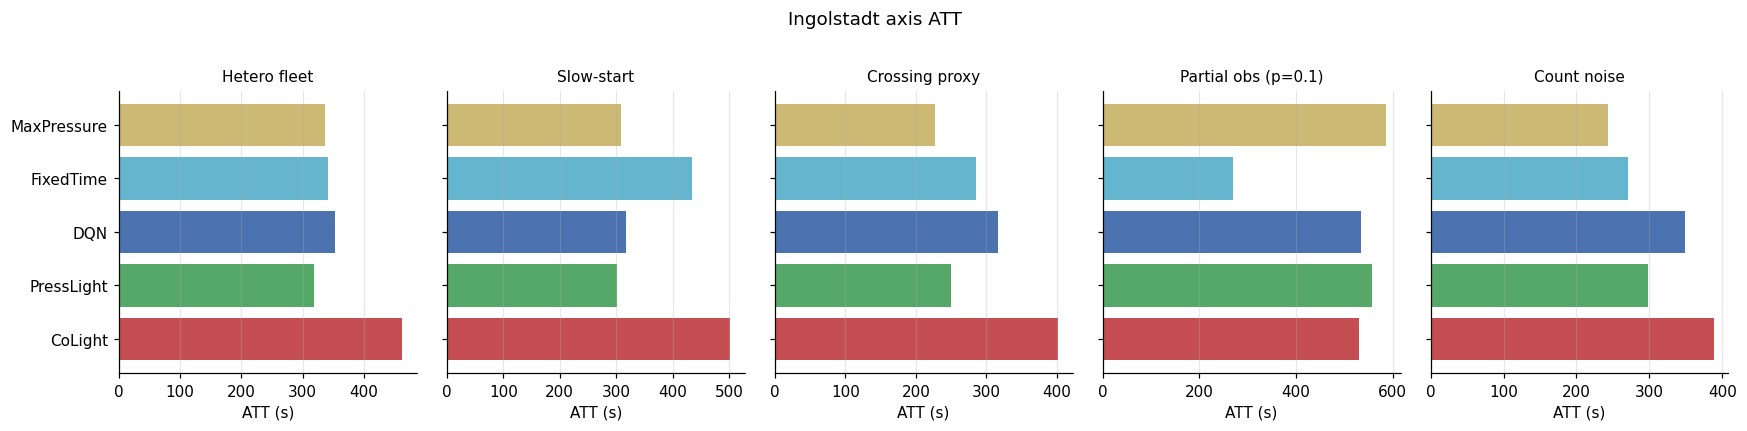

In [7]:
base = df_e200['primary_ATT']
delta = pivot_att.subtract(base, axis=0)
print('Δ ATT vs fixed-200 baseline (positive = worse)')
display(delta.round(1).rename(columns=AXIS_LABEL))

plot_axes = [a for a in AXES if pivot_att[a].notna().any()]
if plot_axes:
    fig, axes = plt.subplots(1, len(plot_axes), figsize=(3.2 * len(plot_axes), 3.8), sharey=True)
    if len(plot_axes) == 1:
        axes = [axes]
    for ax, name in zip(axes, plot_axes):
        vals = [pivot_att.loc[m, name] if pd.notna(pivot_att.loc[m, name]) else float('nan') for m in METHODS]
        ax.barh(METHODS[::-1], vals[::-1], color=[COLORS[m] for m in METHODS[::-1]])
        ax.set_title(AXIS_LABEL[name], fontsize=10)
        ax.set_xlabel('ATT (s)')
        ax.grid(True, axis='x', alpha=0.3)
    fig.suptitle('Ingolstadt axis ATT', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No axis ATT available yet.')


### Axis learning curves (train | test per RL method)


cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


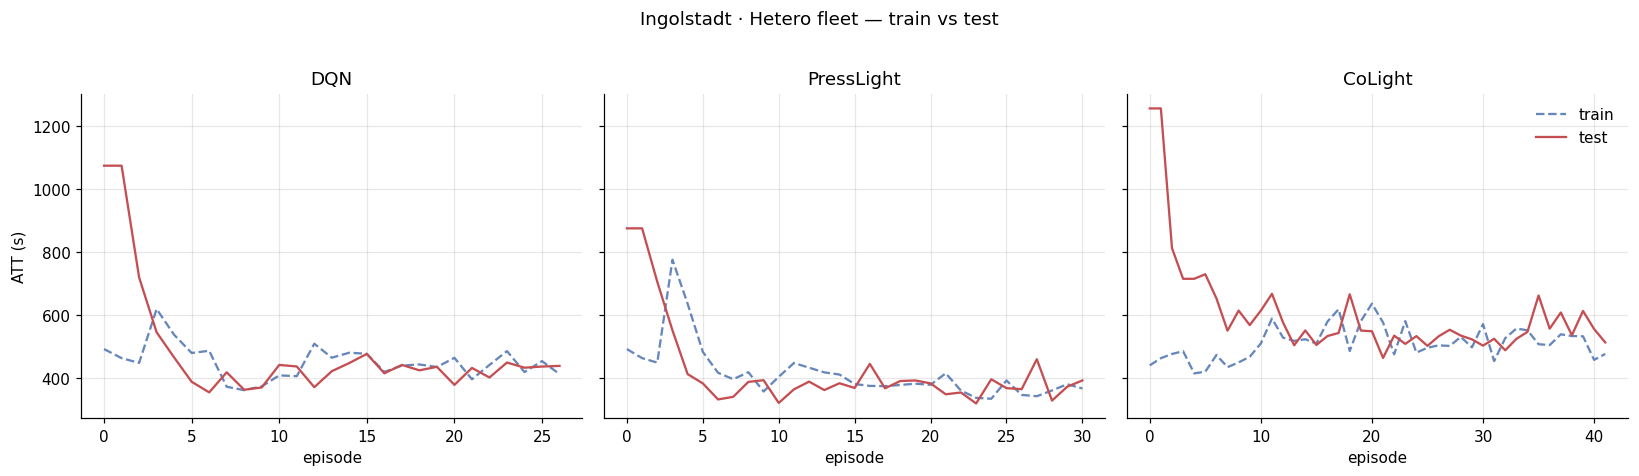

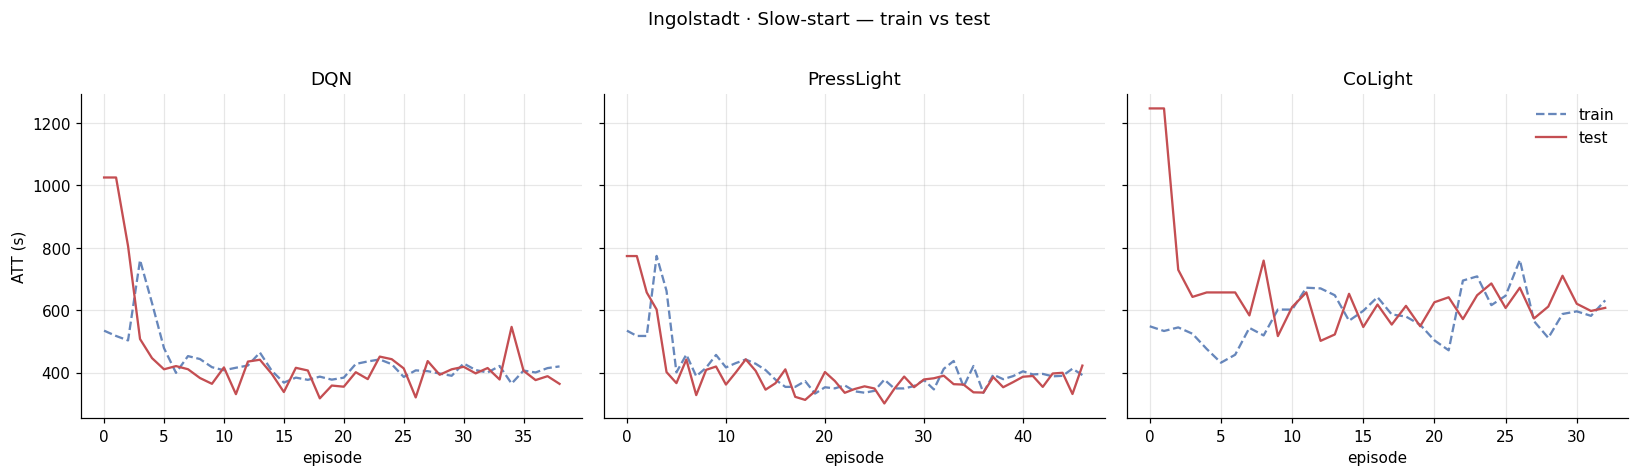

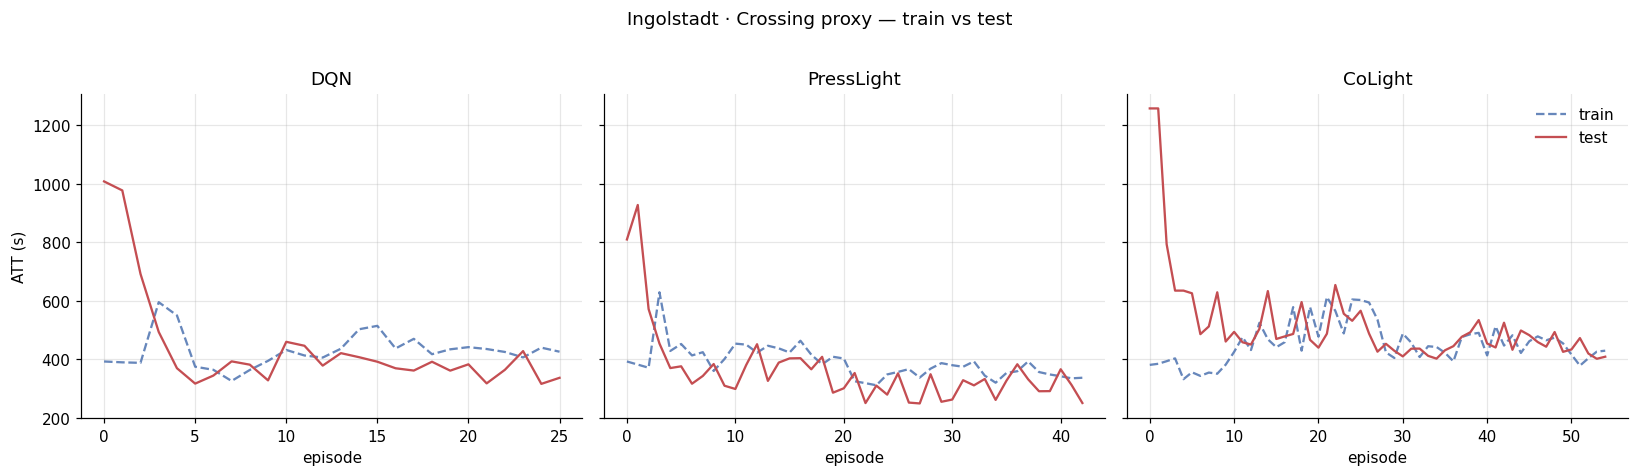

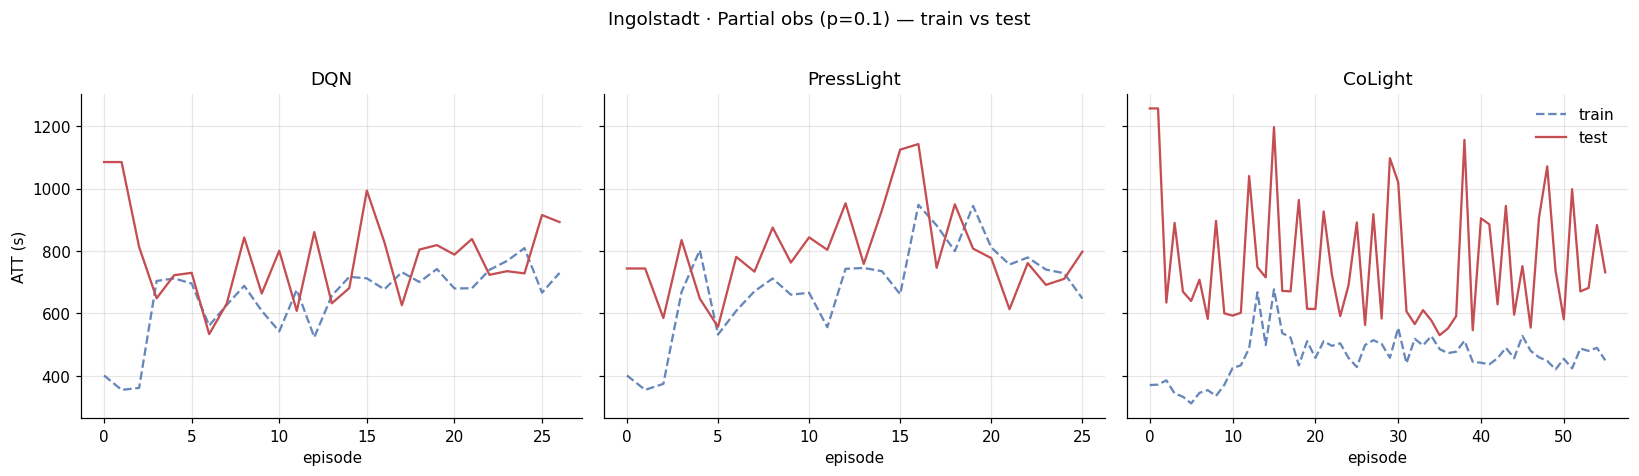

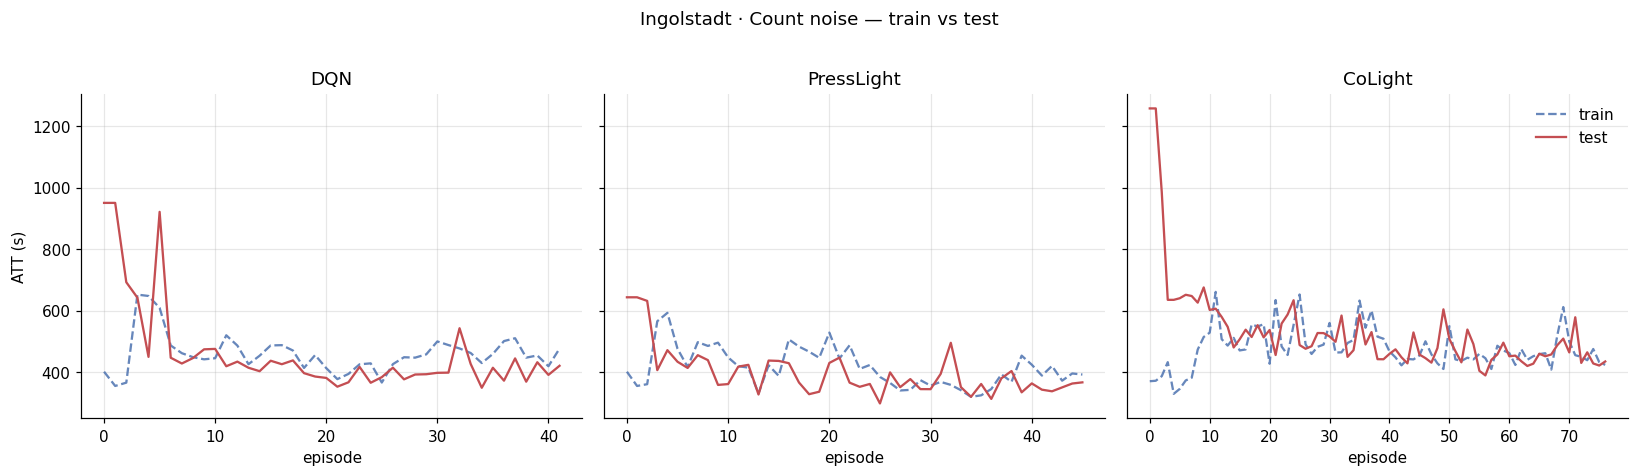

In [8]:
for axis in AXES:
    sub = df_axes[df_axes.axis == axis].set_index('method')
    if (sub.status != 'ok').all() or sub['dtl_path'].isna().all():
        print(f"{AXIS_LABEL[axis]}: {MISSING} / no DTL — sync logger/ then re-run")
        continue
    plot_rl_curves(sub, f'Ingolstadt · {AXIS_LABEL[axis]} — train vs test')


---
## 4 · OD-hub L1 (`odh_l1_1x21_es`)

New hub OD demand, axes off. Primary = **HELDOUT_MEAN**. Job 8811 completed on gpujobs.


            status          prefix  episodes_trained  heldout_ATT final_ATT  primary_ATT                          log note
method                                                                                                                    
MaxPressure     ok  odh_l1_1x21_es               NaN   294.597202      None   294.597202  2026_08_09-15_39_54_DTL.log     
FixedTime       ok  odh_l1_1x21_es               NaN   280.891996      None   280.891996  2026_08_09-15_39_35_DTL.log     
DQN             ok  odh_l1_1x21_es              41.0   247.162282      None   247.162282  2026_08_09-15_40_12_DTL.log     
PressLight      ok  odh_l1_1x21_es              51.0   258.951461      None   258.951461  2026_08_09-15_48_43_DTL.log     
CoLight         ok  odh_l1_1x21_es              81.0   316.321314      None   316.321314  2026_08_09-16_00_28_DTL.log     


cell_1:199: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


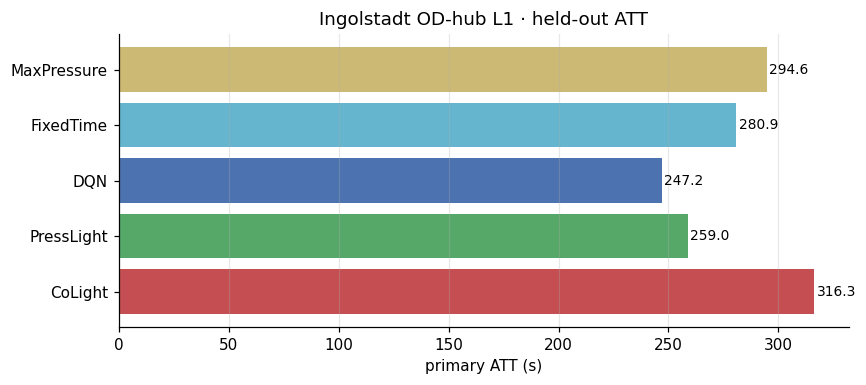

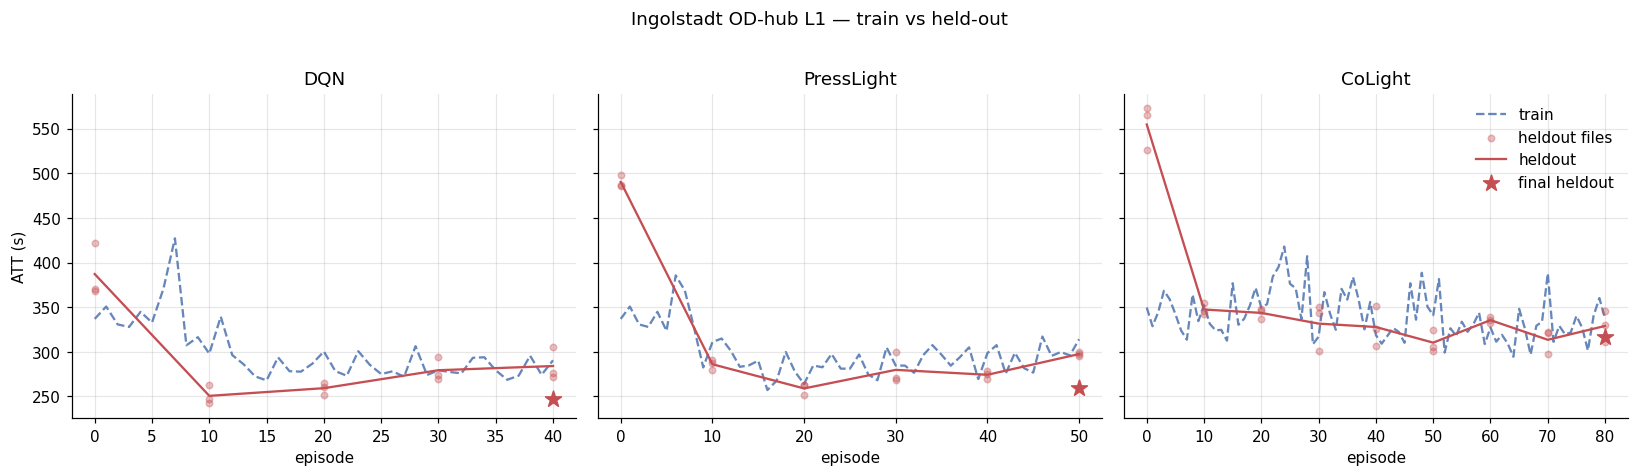

In [9]:
df_l1 = pd.DataFrame([
    try_candidates(
        m,
        [
            (f'{METHOD_SLUG[m]}_odh_l1_1x21', 'odh_l1_1x21_es'),
            (f'{METHOD_SLUG[m]}_odh_l1_1x21', 'smoke_odh_l1_1x21'),
        ],
        prefer_heldout=True,
    )
    for m in METHODS
]).set_index('method')
for m in df_l1.index:
    if df_l1.loc[m, 'status'] == MISSING:
        df_l1.at[m, 'note'] = df_l1.loc[m, 'note'] or 'needs update — sync logger/ from job 8811'

show_table(df_l1, ['status', 'prefix', 'episodes_trained', 'heldout_ATT', 'final_ATT',
                   'primary_ATT', 'log', 'note'])
bar_primary(df_l1, 'Ingolstadt OD-hub L1 · held-out ATT')
plot_rl_curves(df_l1, 'Ingolstadt OD-hub L1 — train vs held-out')


---
## 5 · OD-hub L2 (`odh_l2_1x21_es`)

OD + **realism_full** (hetero + slow-start + crossing + obs stack). Job 8812 completed on gpujobs.


            status          prefix  episodes_trained  heldout_ATT final_ATT  primary_ATT                          log note
method                                                                                                                    
MaxPressure     ok  odh_l2_1x21_es               NaN   301.196682      None   301.196682  2026_08_09-15_39_56_DTL.log     
FixedTime       ok  odh_l2_1x21_es               NaN   288.960481      None   288.960481  2026_08_09-15_39_36_DTL.log     
DQN             ok  odh_l2_1x21_es             101.0   281.515569      None   281.515569  2026_08_09-15_40_17_DTL.log     
PressLight      ok  odh_l2_1x21_es             111.0   277.049783      None   277.049783  2026_08_09-16_03_17_DTL.log     
CoLight         ok  odh_l2_1x21_es              51.0   340.283151      None   340.283151  2026_08_09-16_30_42_DTL.log     


cell_1:199: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_1:284: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


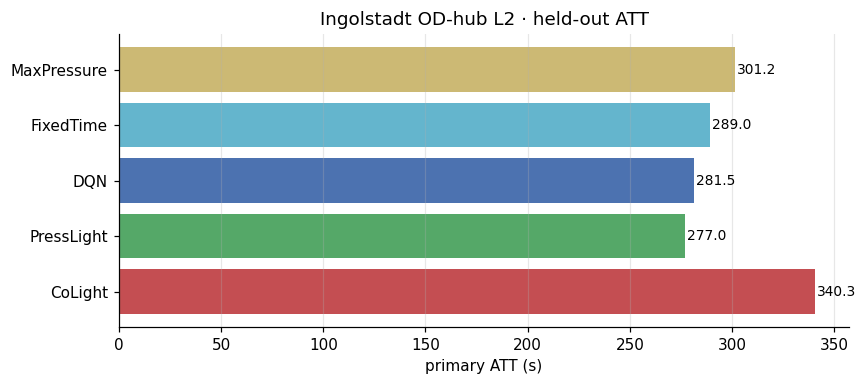

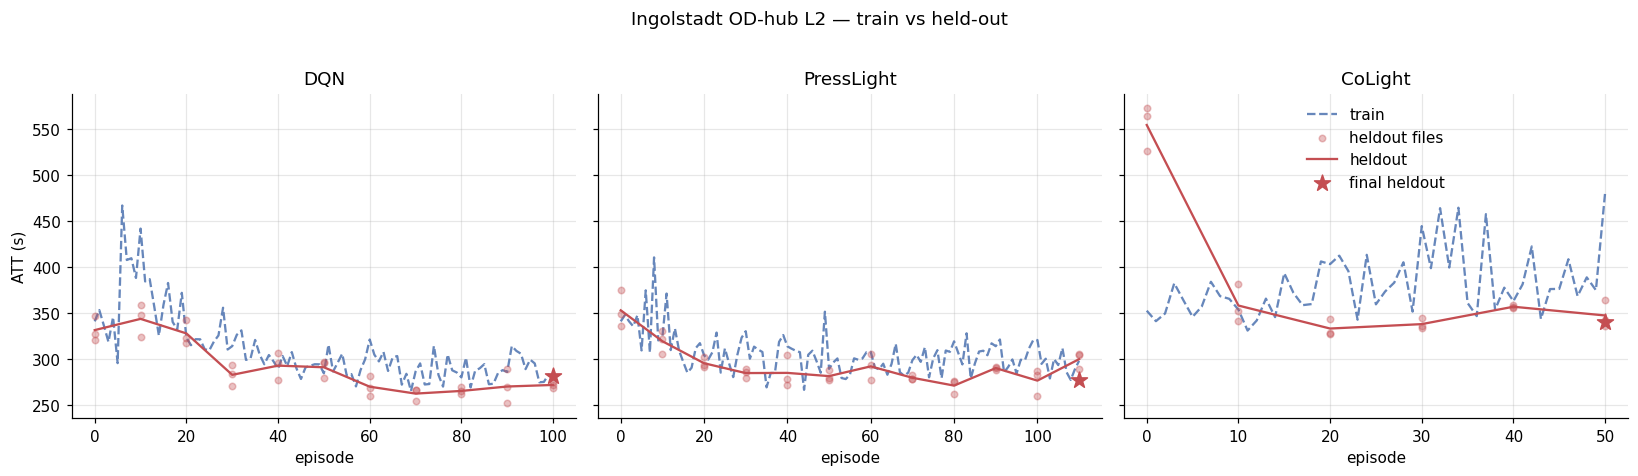

In [10]:
df_l2 = pd.DataFrame([
    try_candidates(
        m,
        [
            (f'{METHOD_SLUG[m]}_odh_l2_1x21', 'odh_l2_1x21_es'),
            (f'{METHOD_SLUG[m]}_odh_l2_1x21', 'smoke_odh_l2_1x21'),
        ],
        prefer_heldout=True,
    )
    for m in METHODS
]).set_index('method')
for m in df_l2.index:
    if df_l2.loc[m, 'status'] == MISSING:
        df_l2.at[m, 'note'] = df_l2.loc[m, 'note'] or 'needs update — sync logger/ from job 8812'

show_table(df_l2, ['status', 'prefix', 'episodes_trained', 'heldout_ATT', 'final_ATT',
                   'primary_ATT', 'log', 'note'])
bar_primary(df_l2, 'Ingolstadt OD-hub L2 · held-out ATT')
plot_rl_curves(df_l2, 'Ingolstadt OD-hub L2 — train vs held-out')


### L1 → L2 (when both synced)


             L1_heldout  L2_heldout L1_status L2_status  Δ (L2−L1)  L1_rank  L2_rank
method                                                                              
MaxPressure      294.60      301.20        ok        ok       6.60      4.0      4.0
FixedTime        280.89      288.96        ok        ok       8.07      3.0      3.0
DQN              247.16      281.52        ok        ok      34.35      1.0      2.0
PressLight       258.95      277.05        ok        ok      18.10      2.0      1.0
CoLight          316.32      340.28        ok        ok      23.96      5.0      5.0


cell_20:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


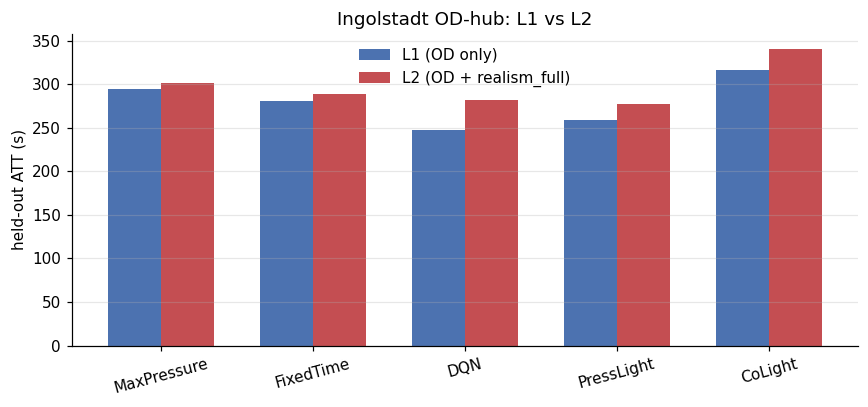

In [11]:
odh = pd.DataFrame({
    'L1_heldout': df_l1['primary_ATT'],
    'L2_heldout': df_l2['primary_ATT'],
    'L1_status': df_l1['status'],
    'L2_status': df_l2['status'],
})
odh['Δ (L2−L1)'] = odh['L2_heldout'] - odh['L1_heldout']
odh['L1_rank'] = odh['L1_heldout'].rank(ascending=True)
odh['L2_rank'] = odh['L2_heldout'].rank(ascending=True)
display(odh.round(2))

if odh[['L1_heldout', 'L2_heldout']].notna().any().any():
    fig, ax = plt.subplots(figsize=(8, 3.8))
    x = range(len(METHODS))
    w = 0.35
    a = [odh.loc[m, 'L1_heldout'] if pd.notna(odh.loc[m, 'L1_heldout']) else 0 for m in METHODS]
    b = [odh.loc[m, 'L2_heldout'] if pd.notna(odh.loc[m, 'L2_heldout']) else 0 for m in METHODS]
    ax.bar([i - w/2 for i in x], a, w, label='L1 (OD only)', color='#4C72B0')
    ax.bar([i + w/2 for i in x], b, w, label='L2 (OD + realism_full)', color='#C44E52')
    ax.set_xticks(list(x))
    ax.set_xticklabels(METHODS, rotation=15)
    ax.set_ylabel('held-out ATT (s)')
    ax.set_title('Ingolstadt OD-hub: L1 vs L2')
    ax.legend(frameon=False)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('L1/L2 held-out not synced yet —', MISSING)


---
## 6 · Comparison to `sumo4x4` — is ranking topology-dependent?

Absolute ATT is **not** comparable (different demand, length, horizon). We compare **ranks**, **who beats MaxPressure**, and **how realism / OD shifts the order**.

4x4 refs: `baseline_early_stop` / `homo_4x4`; axis folders when present; OD-hub `odh_l*_es`.


             1x21_fixed200  1x21_ES  4x4_baseline  1x21_rank  4x4_rank  rank_shift
method                                                                            
MaxPressure         217.84   209.10        171.90        2.0       3.0        -1.0
FixedTime           241.75   248.93        218.39        4.0       5.0        -1.0
DQN                 224.40   236.50        169.90        3.0       2.0         1.0
PressLight          213.00   203.20        174.90        1.0       4.0        -3.0
CoLight             273.30   272.50        169.80        5.0       1.0         4.0


cell_22:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


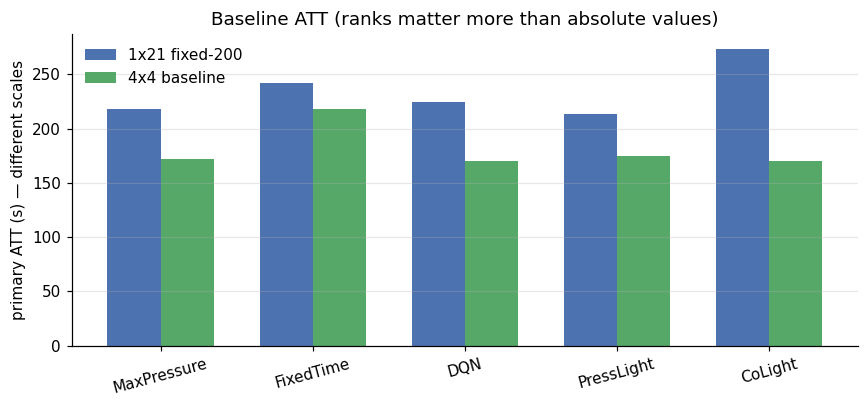

In [12]:
rows_4x4 = []
for m in METHODS:
    slug = METHOD_SLUG[m]
    row = try_candidates(m, [
        (slug, 'baseline_early_stop', 'sumo4x4'),
        (slug, 'homo_4x4', 'sumo4x4'),
        (slug, 'baseline_homo', 'sumo4x4'),
    ])
    rows_4x4.append(row)
df_4x4 = pd.DataFrame(rows_4x4).set_index('method')

vs = pd.DataFrame({
    '1x21_fixed200': df_e200['primary_ATT'],
    '1x21_ES': df_es['primary_ATT'],
    '4x4_baseline': df_4x4['primary_ATT'],
})
vs['1x21_rank'] = vs['1x21_fixed200'].rank(ascending=True)
vs['4x4_rank'] = vs['4x4_baseline'].rank(ascending=True)
vs['rank_shift'] = vs['1x21_rank'] - vs['4x4_rank']
display(vs.round(2))

fig, ax = plt.subplots(figsize=(8, 3.8))
x = range(len(METHODS))
w = 0.35
a = [vs.loc[m, '1x21_fixed200'] if pd.notna(vs.loc[m, '1x21_fixed200']) else 0 for m in METHODS]
b = [vs.loc[m, '4x4_baseline'] if pd.notna(vs.loc[m, '4x4_baseline']) else 0 for m in METHODS]
ax.bar([i - w/2 for i in x], a, w, label='1x21 fixed-200', color='#4C72B0')
ax.bar([i + w/2 for i in x], b, w, label='4x4 baseline', color='#55A868')
ax.set_xticks(list(x))
ax.set_xticklabels(METHODS, rotation=15)
ax.set_ylabel('primary ATT (s) — different scales')
ax.set_title('Baseline ATT (ranks matter more than absolute values)')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
def beat_mp(series):
    mp = series.get('MaxPressure')
    if mp is None or pd.isna(mp):
        return {m: None for m in series.index}
    return {m: (float(series[m]) < float(mp)) if pd.notna(series[m]) else None for m in series.index}

beats = pd.DataFrame({
    '1x21_beats_MP': beat_mp(df_e200['primary_ATT']),
    '4x4_beats_MP': beat_mp(df_4x4['primary_ATT']),
})
display(beats)

# Crossing-proxy stress vs own baseline
cp_1x21, cp_4x4 = {}, {}
for m in METHODS:
    slug = f"{METHOD_SLUG[m]}_crossing_proxy"
    r1 = try_candidates(m, [(slug, 'axis_crossing_proxy_1x21_es')])
    cp_1x21[m] = r1['primary_ATT']
    r4 = try_candidates(m, [
        (slug, 'crossing_proxy_4x4', 'sumo4x4'),
        (slug, 'baseline_crossing_proxy', 'sumo4x4'),
    ])
    cp_4x4[m] = r4['primary_ATT']

cp = pd.DataFrame({
    '1x21_cp': pd.Series(cp_1x21),
    '1x21_base': df_e200['primary_ATT'],
    '4x4_cp': pd.Series(cp_4x4),
    '4x4_base': df_4x4['primary_ATT'],
})
cp['1x21_Δ'] = cp['1x21_cp'] - cp['1x21_base']
cp['4x4_Δ'] = cp['4x4_cp'] - cp['4x4_base']
print('Crossing-proxy Δ vs own baseline (positive = worse)')
display(cp.round(1))

# 4x4 OD-hub for narrative
rows_4_l1, rows_4_l2 = [], []
for m in METHODS:
    slug = METHOD_SLUG[m]
    rows_4_l1.append(try_candidates(m, [
        (f'{slug}_odh_l1', 'odh_l1_es', 'sumo4x4'),
        (f'{slug}_odh_l1', 'odh_l1', 'sumo4x4'),
    ], prefer_heldout=True))
    rows_4_l2.append(try_candidates(m, [
        (f'{slug}_odh_l2', 'odh_l2_es', 'sumo4x4'),
        (f'{slug}_odh_l2', 'odh_l2', 'sumo4x4'),
    ], prefer_heldout=True))
df4_l1 = pd.DataFrame(rows_4_l1).set_index('method')
df4_l2 = pd.DataFrame(rows_4_l2).set_index('method')
odh4 = pd.DataFrame({
    '4x4_L1': df4_l1['primary_ATT'],
    '4x4_L2': df4_l2['primary_ATT'],
})
odh4['Δ L2−L1'] = odh4['4x4_L2'] - odh4['4x4_L1']
print('4x4 OD-hub held-out (reference)')
display(odh4.round(1))


             1x21_beats_MP  4x4_beats_MP
MaxPressure          False         False
FixedTime            False         False
DQN                  False          True
PressLight            True         False
CoLight              False          True


             1x21_cp  1x21_base  4x4_cp  4x4_base  1x21_Δ  4x4_Δ
MaxPressure    227.7      217.8   178.4     171.9     9.9    6.5
FixedTime      285.1      241.7   223.5     218.4    43.4    5.1
DQN            316.2      224.4   172.6     169.9    91.8    2.7
PressLight     249.3      213.0   179.3     174.9    36.3    4.4
CoLight        401.9      273.3   173.1     169.8   128.6    3.3


             4x4_L1  4x4_L2  Δ L2−L1
method                              
MaxPressure   157.2   186.9     29.7
FixedTime     186.6   192.2      5.5
DQN           157.4   221.6     64.2
PressLight    162.3   190.3     28.0
CoLight       156.9   407.5    250.6


Crossing-proxy Δ vs own baseline (positive = worse)
4x4 OD-hub held-out (reference)


### Interpretation

#### Sync status (this refresh)

| Block | Local loggers |
|-------|----------------|
| Baseline fixed-200 (`homo_1x21`) | **OK** (all 5) |
| Baseline early-stop (`homo_1x21_es`) | **OK** (restored from `feat/early-stop-episodes`) |
| Single-axis × 5 methods | **OK** (all 25) |
| OD-hub L1 / L2 | **OK** (all 10) |

#### Is ranking topology-dependent?

**Yes.** On `sumo4x4`, RL usually sits near or below MaxPressure. On Ingolstadt **1×21** (fixed-200 homo): **PressLight (213) < MaxPressure (218) < DQN (224) < FixedTime (242) < CoLight (273)**. Long-chain arterial + peak demand favors pressure-aligned control; graph CoLight lags.

#### What single realism axes do (1×21, Δ vs fixed-200)

| Axis | MaxPressure | PressLight | DQN | FixedTime | CoLight |
|------|-------------|------------|-----|-----------|---------|
| Crossing proxy | **+10** | +36 | +92 | +43 | +129 |
| Count noise | +26 | +85 | +125 | +29 | +116 |
| Hetero | +118 | +106 | +129 | +101 | +190 |
| Slow-start | +91 | +89 | +94 | +193 | +229 |
| Partial obs | **+369** | +344 | +309 | +29 | +257 |

- **Crossing:** MP almost flat; RL pays more.
- **Partial obs:** catastrophic for MP/RL (ATT → 500–590 s); FixedTime barely moves (same open-loop plan).
- **Hetero / slow-start:** large ATT tax for everyone; FixedTime especially hurt by slow-start.

#### L1 vs L2 (OD-hub held-out)

| Method | L1 held-out | L2 held-out | Δ |
|--------|-------------|-------------|---|
| **DQN** | **247.2** | 281.5 | +34.4 |
| PressLight | 259.0 | **277.0** | +18.1 |
| FixedTime | 280.9 | 289.0 | +8.1 |
| MaxPressure | 294.6 | 301.2 | +6.6 |
| CoLight | 316.3 | 340.3 | +24.0 |

Under hub OD (L1), **DQN wins** and **FixedTime beats MaxPressure**. Under L2 (OD + realism_full), **PressLight wins**; MP stays close to FT; CoLight remains last. Rankings **do not** match homo e200 — demand realism reshuffles the leaderboard even before plant/sensor axes.


---
## Coverage summary


In [14]:
def cov(df, name):
    s = df['status'] if 'status' in df.columns else pd.Series(dtype=str)
    return {
        'block': name,
        'ok': int((s == 'ok').sum()),
        'partial': int((s == 'partial').sum()),
        'needs_update': int((s == MISSING).sum()),
        'total': len(df),
    }

summary = pd.DataFrame([
    cov(df_es.reset_index(), '1 baseline ES'),
    cov(df_e200.reset_index(), '2 baseline fixed-200'),
    cov(df_axes, '3 axes 5×5'),
    cov(df_l1.reset_index(), '4 OD-hub L1'),
    cov(df_l2.reset_index(), '5 OD-hub L2'),
])
display(summary)
sync_hint()


                  block  ok  partial  needs_update  total
0         1 baseline ES   5        0             0      5
1  2 baseline fixed-200   5        0             0      5
2            3 axes 5×5  25        0             0     25
3           4 OD-hub L1   5        0             0      5
4           5 OD-hub L2   5        0             0      5


Re-sync ONLY logger trees from gpujobs (Mac):
  rsync -avz --progress \
    --include='*/' --include='**/sumo1x21/**/logger/**' --exclude='*' \
    mmirzata@172.20.48.59:~/LibSignalFork/data/output_data/tsc/ \
    data/output_data/tsc/
On gpujobs, verify logs exist first, e.g.:
  ls data/output_data/tsc/sumo_dqn_hetero/sumo1x21/axis_hetero_1x21_es/logger/
  ls data/output_data/tsc/sumo_dqn_odh_l1_1x21/sumo1x21/odh_l1_1x21_es/logger/
